# ERROR MAPS

In [16]:
# States boundary file
import geopandas as gpd
states_path = 'D:/ArcGIS/Boundaries/States/conterminous_states_usgs/Conterminous_States_usgs.shp'
states = gpd.read_file(states_path)

In [17]:
# Read in COMID centroids (1m 9s)
import geopandas as gpd
sp_dir = "D:/Data/Spatial/NHDPlusV2_Centroids/"

cats_centroids_path = sp_dir + "NHDPlusV2_Cat_All_centroid_point.shp"
cats_p = gpd.read_file(cats_centroids_path)

In [ ]:
# Load Prediction Results
import pandas as pd
import polars as pl
#import pyarrow as pa
#import pyarrow.parquet as pq

future_dir = 'C:/Users/MPennino/OneDrive - Environmental Protection Agency (EPA)/Projects/OASES/Data/Future_NO3/'

filename0 = 'torch_predictions_current_All_COMID_sw.parquet' 
#filename0 = 'torch_predictions_current_All_COMID_gw.parquet'  

preds_curr = pl.read_parquet(future_dir + filename0)
preds_curr = preds_curr.to_pandas()


In [8]:
preds_curr.head()

,COMID,Pred_Viol_Prob
0,-504212,NaN
1,-504211,NaN
2,-504210,NaN
3,-504209,NaN
4,-504208,NaN


In [6]:
# Load Observation Dataset

dataset1 = 'Dataset_RF_Model_SW_COMIDS.csv'
#dataset1 = 'Dataset_RF_Model_GW_COMIDS.csv'

input_data = pd.read_csv(future_dir+dataset1)

obs_data = input_data[['COMID','Viol_Class']]


In [12]:
obs_data.columns

Index(['COMID', 'Viol_Class'], dtype='str')

In [10]:
# Convert Predicted PRobability to Violation Class
import numpy as np
preds_curr['Pred_Class'] = np.where(preds_curr['Pred_Viol_Prob'] > 0.5, 1, 0)

In [15]:
# Merge Obs and Pred datasets

obs_pred = obs_data.merge(preds_curr, on="COMID", how="left")

# Calculate Error Categories
# errmap$error[errmap$Viol_Class == 1 & errmap$Prediction >= 0.5] = "True Positive"
# errmap$error[errmap$Viol_Class == 0 & errmap$Prediction < 0.5] = "True Negative"
# errmap$error[errmap$Viol_Class == 1 & errmap$Prediction < 0.5] = "False Negative"
# errmap$error[errmap$Viol_Class == 0 & errmap$Prediction >= 0.5] = "False Positive"
obs_pred['error'] = "Unknown"
#obs_pred['error'] = np.where(obs_pred['Viol_Class']==1 & obs_pred['Pred_Class']==1,"True Positive",obs_pred['error'] )

condition1 = (obs_pred['Viol_Class'] == 1) & (obs_pred['Pred_Class'] == 1)
condition2 = (obs_pred['Viol_Class'] == 0) & (obs_pred['Pred_Class'] == 0)
condition3 = (obs_pred['Viol_Class'] == 1) & (obs_pred['Pred_Class'] == 0)
condition4 = (obs_pred['Viol_Class'] == 0) & (obs_pred['Pred_Class'] == 1)

obs_pred.loc[condition1, 'error'] = "True Positive"
obs_pred.loc[condition2, 'error'] = "True Negative"
obs_pred.loc[condition3, 'error'] = "False Negative"
obs_pred.loc[condition4, 'error'] = "False Positive"

# Get the unique strings
unique_array = obs_pred['error'].unique()
print(unique_array)



<ArrowStringArray>
['False Positive', 'True Negative', 'True Positive']
Length: 3, dtype: str


# MAPPING

In [18]:
# Merge shap results with Shapefile
obs_pred_s = cats_p.merge(obs_pred, on="COMID", how="left")

# remove NA rows
obs_pred_s = obs_pred_s.dropna(subset=['error'])

In [23]:
from matplotlib.colors import ListedColormap

mycolors = ListedColormap(['yellow','green','red','blue']) # Convert the list into a Matplotlib colormap object


In [34]:
color_map = {
    "True Negative": "lightgreen",
    "False Positive": "#DAA520",
    "False Negative": "blue",
    "True Positive": "red"
}

# Map the dictionary directly to create a new column of color strings
obs_pred_s["map_color"] = obs_pred_s["error"].map(color_map).fillna("grey")

In [39]:
points1 =  obs_pred_s[obs_pred_s['error'] != 'False Positive']
points2 =  obs_pred_s[obs_pred_s['error'] == 'False Positive']

# Get the unique strings
unique_array = points2['error'].unique()
print(unique_array)

<ArrowStringArray>
['False Positive']
Length: 1, dtype: str


C:\Users\MPennino\AppData\Local\Temp\ipykernel_158872\3294629695.py:28: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  points1.plot(
C:\Users\MPennino\AppData\Local\Temp\ipykernel_158872\3294629695.py:40: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  points2.plot(
C:\Users\MPennino\AppData\Local\Temp\ipykernel_158872\3294629695.py:52: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  points3.plot(


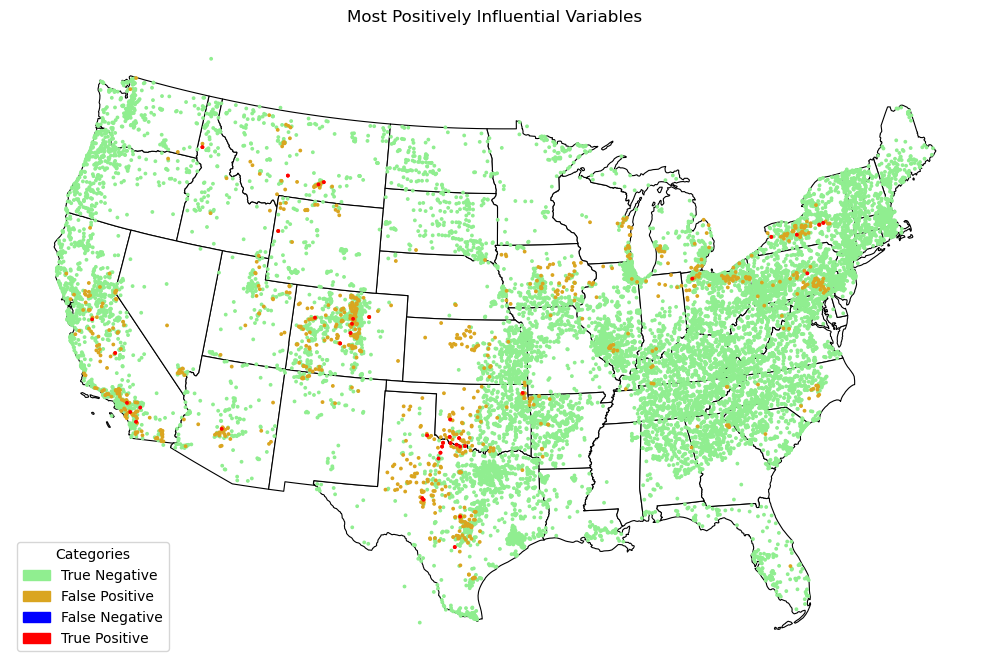

In [43]:
# MAPING Max Shap Variable
# This maps state boundaries on bottom
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Subsetting to make False Postive Category on top
points1 =  obs_pred_s[obs_pred_s['error'] != 'False Positive']
points2 =  obs_pred_s[obs_pred_s['error'] == 'False Positive']
points3 =  obs_pred_s[obs_pred_s['error'] == 'True Positive']

# CRITICAL: Ensure both datasets share the exact same Coordinate Reference System (CRS)
if points1.crs != states.crs:
    points1 = points1.to_crs(states.crs)

# 2. Create a single figure and axis object
fig, ax = plt.subplots(figsize=(10, 10))

# 3. Plot the states boundaries FIRST (as the background)
states.plot(
    ax=ax, 
    color='white',      # Fill color of the states
    edgecolor='black',  # Boundary line color
    linewidth=0.8
)

# 4. Plot the points SECOND (layered on top)
points1.plot(
    ax=ax,              # Draws it on the exact same axis as the states
    column='error',  
    categorical=True,               
    legend=True,                    
    marker='o',  
    #facecolors='none', # for open circles                   
    markersize=3, 
    color= points1['map_color']#,               

)

points2.plot(
    ax=ax,              # Draws it on the exact same axis as the states
    column='error',  
    categorical=True,               
    legend=True,                    
    marker='o',  
    #facecolors='none', # for open circles                   
    markersize=3, 
    color= points2['map_color']#,               

)

points3.plot(
    ax=ax,              # Draws it on the exact same axis as the states
    column='error',  
    categorical=True,               
    legend=True,                    
    marker='o',  
    #facecolors='none', # for open circles                   
    markersize=3, 
    color= points3['map_color']#,               

)

# Manually build the legend
legend_handles = [
    mpatches.Patch(color=color, label=label) 
    for label, color in color_map.items()
]
ax.legend(handles=legend_handles, title="Categories")

# Remove the outside axis, ticks, and frame completely
ax.set_axis_off()
plt.title("Most Positively Influential Variables")
plt.tight_layout()
plt.show()